# Rice Field (Sawah) vs Non-Rice Field Classification: Sentinel-2A + Random Forest (scikit-eo)

Adapted from the scikit-eo tutorial *01. Machine Learning*.

- **Imagery:** Sentinel-2A L2A downloaded from Copernicus Browser as separate band TIFFs (B02, B03, B04, B08, B11, B12)
- **Samples:** polygon shapefile from geojson.io (`class` = `sawah` / `bukan sawah`)
- **Output:** classification map as a `.tif`



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.0 Libraries

In [ ]:
!pip install scikeo dbfread -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 70.2 MB/s eta 0:00:00


In [ ]:
import os, glob, zipfile
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scikeo.mla import MLA
from scikeo.process import extract
from scikeo.plot import plotRGB
from scikeo.writeRaster import writeRaster

## 2.0 Input data

### 2.1 Settings

In [ ]:
IMAGES_ZIP = "Browser_images.zip"   # zip from Copernicus (band TIFFs)
SHAPE_ZIP  = "sawah.zip"            # zipped shapefile

IMAGES_DIR = "images"               # unzip destination for the TIFFs
SHAPE_DIR  = "shapefile"            # unzip destination for the shapefile
STACK_PATH = "sentinel2_stack.tif"  # 6-band image created below
OUT_DIR    = "results"              # outputs go here

### 2.2 Build the 6-band image from the Copernicus band files

Each band comes as its own TIFF. They are stacked into one file in this order: **B02 (Blue), B03 (Green), B04 (Red), B08 (NIR), B11 (SWIR1), B12 (SWIR2)**.

In [ ]:
with zipfile.ZipFile(IMAGES_ZIP) as z:
    z.extractall(IMAGES_DIR)

BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]

def find_band(b):
    # search recursively; ignore the True_color file
    hits = [f for f in glob.glob(os.path.join(IMAGES_DIR, "**", "*"), recursive=True)
            if f.lower().endswith((".tif", ".tiff")) and f"_{b}_" in os.path.basename(f)]
    if not hits:
        raise FileNotFoundError(f"Band {b} not found in {IMAGES_DIR}. Check the zip contents.")
    return hits[0]

files = [find_band(b) for b in BANDS]
for b, f in zip(BANDS, files):
    print(b, "->", os.path.basename(f))

with rasterio.open(files[0]) as s:
    prof = s.profile
prof.update(count=len(BANDS), dtype="float32", compress="deflate")

with rasterio.open(STACK_PATH, "w", **prof) as dst:
    for i, (b, f) in enumerate(zip(BANDS, files), 1):
        with rasterio.open(f) as s:
            dst.write(s.read(1).astype("float32"), i)
        dst.set_band_description(i, b)

print("Saved", STACK_PATH)

B02 -> 2026-07-10-00_00_2026-07-10-23_59_Sentinel-2_L2A_B02_(Raw).tiff
B03 -> 2026-07-10-00_00_2026-07-10-23_59_Sentinel-2_L2A_B03_(Raw).tiff
B04 -> 2026-07-10-00_00_2026-07-10-23_59_Sentinel-2_L2A_B04_(Raw).tiff
B08 -> 2026-07-10-00_00_2026-07-10-23_59_Sentinel-2_L2A_B08_(Raw).tiff
B11 -> 2026-07-10-00_00_2026-07-10-23_59_Sentinel-2_L2A_B11_(Raw).tiff
B12 -> 2026-07-10-00_00_2026-07-10-23_59_Sentinel-2_L2A_B12_(Raw).tiff
Saved sentinel2_stack.tif


### 2.3 Load the image and the shapefile

In [ ]:
with zipfile.ZipFile(SHAPE_ZIP) as z:
    z.extractall(SHAPE_DIR)

shp_files = glob.glob(os.path.join(SHAPE_DIR, "**", "*.shp"), recursive=True)
assert shp_files, "No .shp file found inside the shapefile zip"

img  = rasterio.open(STACK_PATH)
poly = gpd.read_file(shp_files[0])
print("Image  :", img.count, "bands,", img.width, "x", img.height, ",", img.crs)
print("Samples:", len(poly), "features, CRS", poly.crs)

Image  : 6 bands, 332 x 592 , EPSG:4326
Samples: 100 features, CRS EPSG:4326


### 2.4 Clean the shapefile

The shapefile contains polygons (not points), and may include empty features and duplicate polygons. These are removed first.

In [ ]:
poly = poly.to_crs(img.crs)                                    # same CRS as the image
poly = poly[poly.geometry.notna() & ~poly.geometry.is_empty]   # drop empty geometries
poly = poly.assign(_wkt=poly.geometry.to_wkt()).drop_duplicates("_wkt").drop(columns="_wkt")
poly = poly.reset_index(drop=True)
print(poly["class"].value_counts())

class
sawah          47
bukan sawah    47
Name: count, dtype: int64


### 2.5 Polygons to point samples (pixels)

`extract()` from scikit-eo only accepts **points**, so each polygon is converted into the centres of the pixels inside it. At most `MAX_PER_POLY` pixels are taken per polygon, so large polygons do not dominate and the two classes stay more balanced.

In [ ]:
MAX_PER_POLY = 30
rng = np.random.default_rng(42)

rows = []
for i, r in poly.iterrows():
    m = rasterize([(r.geometry, 1)], out_shape=(img.height, img.width),
                  transform=img.transform, all_touched=False).astype(bool)
    if m.sum() == 0:                                   # very small polygon
        m = rasterize([(r.geometry, 1)], out_shape=(img.height, img.width),
                      transform=img.transform, all_touched=True).astype(bool)
    rr, cc = np.where(m)
    if len(rr) > MAX_PER_POLY:
        k = rng.choice(len(rr), MAX_PER_POLY, replace=False)
        rr, cc = rr[k], cc[k]
    for a, b in zip(rr, cc):
        x, y = img.xy(a, b)
        rows.append((r["class"], x, y))

pts = pd.DataFrame(rows, columns=["class", "x", "y"])
pts = gpd.GeoDataFrame(pts[["class"]], geometry=gpd.points_from_xy(pts.x, pts.y), crs=img.crs)
print(len(pts), "sample points")
print(pts["class"].value_counts())

1841 sample points
class
sawah          1378
bukan sawah     463
Name: count, dtype: int64


## 3.0 Extract spectral values and train Random Forest

In [ ]:
endm = extract(img, pts)          # first column = class, then band1..band6

# drop pixels with no data (all bands = 0)
band_cols = [c for c in endm.columns if c.startswith("band")]
nodata = (endm[band_cols] == 0).all(axis=1)
print(f"No-data pixels removed: {nodata.sum()} of {len(endm)}")
assert nodata.mean() < 0.2, "Too many empty pixels: check the AoI/date used when downloading from Copernicus"
endm = endm[~nodata].reset_index(drop=True)

# scikit-eo needs numeric classes
class_map = {"sawah": 1, "bukan sawah": 2}
endm["class"] = endm["class"].map(class_map)
print(endm["class"].value_counts())
endm.head()

No-data pixels removed: 0 of 1841
class
1    1378
2     463
Name: count, dtype: int64


,class,band1,band2,band3,band4,band5,band6
0,1,0.0407,0.1050,0.1213,0.2866,0.3121,0.2352
1,1,0.0181,0.0789,0.0757,0.3387,0.2865,0.2039
2,1,0.0291,0.0907,0.1267,0.2504,0.3130,0.2327
3,1,0.0302,0.0922,0.1086,0.3025,0.2921,0.2056
4,1,0.0096,0.0748,0.0729,0.3404,0.2819,0.1968


In [ ]:
inst = MLA(image=img, endmembers=endm)
rf_class = inst.RF(training_split=0.8, random_state=42)

## 4.0 Results

In [ ]:
print("Overall accuracy:", rf_class.get("Overall_Accuracy"))
print("Kappa index     :", rf_class.get("Kappa_Index"))
matrix = rf_class.get("Confusion_Matrix")
matrix

Overall accuracy: 0.959349593495935
Kappa index     : 0.8867565521615484


,1,2,Total,Users_Accuracy,Commission
1,275.000000,6.000000,281.0,97.864769,2.135231
2,9.000000,79.000000,88.0,89.772727,10.227273
Total,284.000000,85.000000,NaN,NaN,NaN
Producer_Accuracy,96.830986,92.941176,NaN,NaN,NaN
Omission,3.169014,7.058824,NaN,NaN,NaN


In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)
matrix.to_csv(os.path.join(OUT_DIR, "confusion_matrix.csv"), sep=";", index=True, header=True)

Classification map. Areas with no data (outside the AoI) are set to 0 (white). **1 = sawah, 2 = non-sawah.**

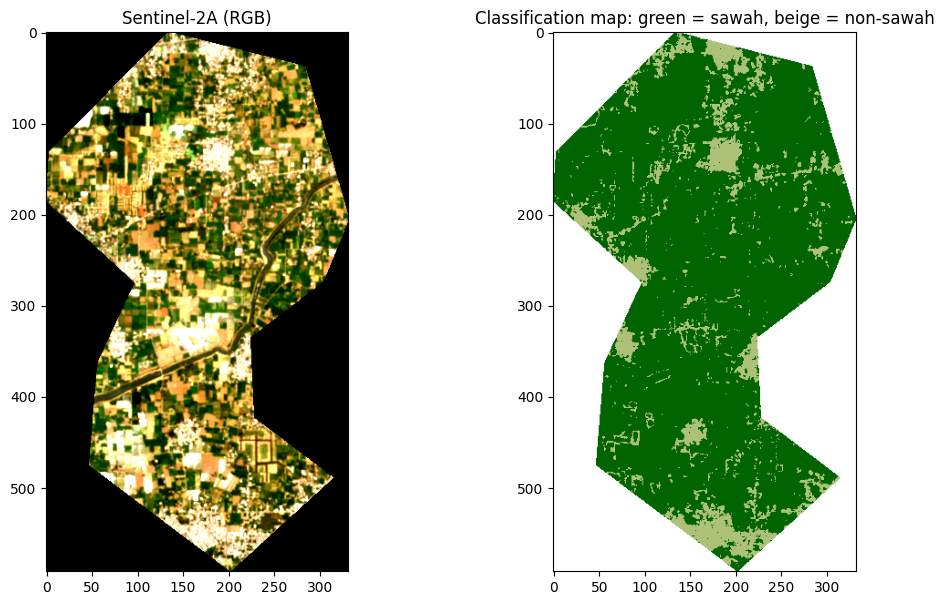

In [ ]:
class_arr = rf_class.get("Classification_Map").astype("float32")
class_arr[np.all(img.read() == 0, axis=0)] = 0

palette = mpl.colors.ListedColormap(["white", "darkgreen", "#ADC178"])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))
plotRGB(img, bands=[3, 2, 1], title="Sentinel-2A (RGB)", ax=axes[0])
axes[1].imshow(class_arr, cmap=palette, vmin=0, vmax=2)
axes[1].set_title("Classification map: green = sawah, beige = non-sawah")
axes[1].grid(False)
plt.show()

Save the result as a `.tif`.

In [ ]:
writeRaster(arr=class_arr, image=img, filename="Sentinel2_Sawah_Label",
            filepath=OUT_DIR, n=1)
print(os.listdir(OUT_DIR))

['confusion_matrix.csv', 'Sentinel2_Sawah_Label.tif']


## 5.0 Download results (Colab)

Run the next cell to download the output files, or use the Files panel on the left.

In [ ]:
try:
    from google.colab import files as colab_files
    for f in os.listdir(OUT_DIR):
        colab_files.download(os.path.join(OUT_DIR, f))
except ImportError:
    print("Not running in Colab: find the outputs in the", OUT_DIR, "folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>